#**Import**

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [24]:
  import tensorflow as tf
  (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

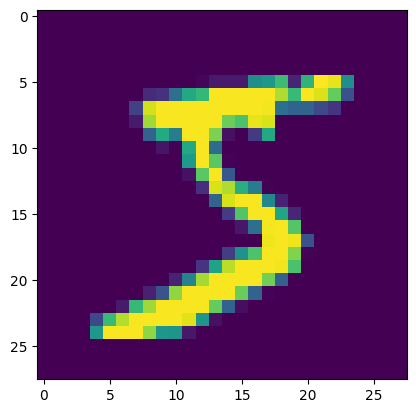

In [25]:
plt.imshow(x_train[0])

In [26]:
#@title Preprocess the data ( these are Numpy arrays)
x_train = torch.tensor(x_train.reshape(60000,784)/255,dtype=torch.float32)
x_test = torch.tensor(x_test.reshape(10000,784)/255,dtype=torch.float32)
y_train = torch.tensor(y_train,dtype=torch.long)
y_test = torch.tensor(y_test,dtype=torch.int64)


In [27]:
#@title Regression
w= torch.randn((784,10)) # removed extra space
b= torch.randn(10,)

In [28]:
w

tensor([[-7.8805e-01,  3.9174e-01, -6.3265e-01,  ..., -1.1783e+00,
          1.8250e+00,  6.7943e-01],
        [ 8.7180e-01,  6.2136e-01, -1.8615e+00,  ..., -1.1874e+00,
         -1.9906e+00, -6.7297e-01],
        [-5.3490e-01,  3.9357e-01,  6.8126e-01,  ..., -9.0857e-01,
         -1.0777e+00,  6.1515e-02],
        ...,
        [-4.4866e-01, -2.4646e-01,  7.4559e-02,  ...,  2.9965e-01,
          4.6239e-01,  1.5627e+00],
        [ 7.9432e-04,  2.0800e+00,  5.7775e-01,  ...,  5.5814e-01,
          4.0273e-01, -8.1010e-01],
        [ 1.3153e+00,  1.2374e+00, -3.0802e+00,  ..., -1.0829e+00,
          1.8662e+00, -9.9133e-01]])

In [29]:
b

tensor([ 0.8078,  1.1017, -1.3183,  0.7139, -0.8546, -0.4858,  0.1125, -0.8249,
        -0.9742,  0.9614])

In [30]:
x2 = x_train @ w + b
print(np.shape(x2))


torch.Size([60000, 10])


In [31]:
#@title NN from scratch
wights = torch.randn((784,10),requires_grad=True)
bias = torch.zeros(10,requires_grad=True)

In [32]:
#@title model 0
def model_0(inputs):
  outputs = inputs @ wights + bias
  return outputs


In [33]:
prob = model_0(x_train)
prob

tensor([[-10.3095,  -1.9843, -10.2920,  ...,  -6.0420, -17.9244,   1.7858],
        [  4.4167,   8.6820, -12.7084,  ...,  10.9087, -13.3242,   7.4226],
        [  8.3862, -11.0727,  -2.5998,  ...,  -5.2245,   3.4680,  -6.3277],
        ...,
        [  6.0704,  -6.9638, -10.6565,  ...,  -3.7005, -12.7963,  -7.8900],
        [ -3.4156,  12.6019, -11.1368,  ...,   8.7020,   0.4040,   4.0627],
        [ -3.8901,   7.8585, -13.6057,  ...,  -3.5205,  -6.4441,   2.2741]],
       grad_fn=<AddBackward0>)

In [34]:
#@title soft max
x= torch.tensor([1,2,3,4], dtype=torch.float32)
print(np.exp(x))
print(x.exp())
x.exp().sum()
x.exp()/ x.exp( ).sum()

#@title log- soft max
def log_softmax(x):
  return x-x.exp().sum(-1).log().unsqueeze(-1)
log_softmax(x)


tensor([ 2.7183,  7.3891, 20.0855, 54.5981])
tensor([ 2.7183,  7.3891, 20.0855, 54.5981])


tensor([-3.4402, -2.4402, -1.4402, -0.4402])

In [35]:
x=torch.tensor([[1,2,3,],[4,5,6]],dtype=torch.float32)
x.shape
x.exp().sum(1,keepdim=True).log()


tensor([[3.4076],
        [6.4076]])

In [36]:
def model_1(inputs) :
  outputs = inputs @ wights + bias
  return log_softmax(outputs)

In [37]:
prob = model_1(x_train)
prob

tensor([[-1.3296e+01, -4.9707e+00, -1.3278e+01,  ..., -9.0285e+00,
         -2.0911e+01, -1.2007e+00],
        [-6.6315e+00, -2.3663e+00, -2.3757e+01,  ..., -1.3954e-01,
         -2.4372e+01, -3.6256e+00],
        [-7.7934e-03, -1.9467e+01, -1.0994e+01,  ..., -1.3619e+01,
         -4.9260e+00, -1.4722e+01],
        ...,
        [-1.1009e+00, -1.4135e+01, -1.7828e+01,  ..., -1.0872e+01,
         -1.9968e+01, -1.5061e+01],
        [-1.6039e+01, -2.1018e-02, -2.3760e+01,  ..., -3.9209e+00,
         -1.2219e+01, -8.5602e+00],
        [-1.1770e+01, -2.1365e-02, -2.1486e+01,  ..., -1.1400e+01,
         -1.4324e+01, -5.6058e+00]], grad_fn=<SubBackward0>)

In [38]:
#@title Log-likelhood
def nll(prob,target):
  return -prob[range(target.shape[0]),target].mean()

In [39]:
A=np.arange(30).reshape(5,6,)
print(A)
A[range(5),[1,0,1,0,1]]

[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]
 [12 13 14 15 16 17]
 [18 19 20 21 22 23]
 [24 25 26 27 28 29]]


array([ 1,  6, 13, 18, 25])

In [40]:
loss_func = nll
loss_func(prob=prob,target=y_train)


tensor(11.9310, grad_fn=<NegBackward0>)

In [41]:
def accuracy(prob,target):
  pred = torch.argmax(prob,dim= -1 )
  return (pred==target).float().mean()

In [42]:
accuracy(prob=prob,target=y_train)

tensor(0.0717)

In [43]:
#@title Training
torch.randint(10,(1,))

tensor([6])

In [44]:
# epochs = 1000
# batch_size = 64
# lr = 0.01
# for epoch in range(epochs):
#   idx = torch.randint(len(x_train),(batch_size,))
#   xs = x_train[idx]
#   ys = y_train[idx]
#   prob = model_1(xs)
#   loss = loss_func(prob,ys)
#   loss.backward()
#   if epoch % 100 == 0:
#     print(loss)

#   with torch.no_grad():


#     weights -= weights.grad*  lr
#     bias -= bias.grad lr
#     wights.grad.zero_()
#     bias.grad.zero_()

# def loss_func():
#   return nll




In [45]:
epochs = 1000
batch_size = 64
lr = 0.01

# Create an optimizer
# !pip install torch
import torch
optimizer = torch.optim.SGD([wights, bias], lr=lr)

for epoch in range(epochs):
  idx = torch.randint(len(x_train),(batch_size,))
  xs = x_train[idx]
  ys = y_train[idx]
  prob = model_1(xs)
  loss = loss_func(prob,ys)
  loss.backward()
  if epoch % 100 == 0:
    print(loss)

  with torch.no_grad():
    # Use the optimizer to update the weights and biases
    optimizer.step()

    # Zero the gradients after the update
    optimizer.zero_grad()

def loss_func():
  return nll

tensor(10.6130, grad_fn=<NegBackward0>)
tensor(8.3428, grad_fn=<NegBackward0>)
tensor(7.4313, grad_fn=<NegBackward0>)
tensor(6.7164, grad_fn=<NegBackward0>)
tensor(6.7891, grad_fn=<NegBackward0>)
tensor(6.8739, grad_fn=<NegBackward0>)
tensor(5.9836, grad_fn=<NegBackward0>)
tensor(3.2195, grad_fn=<NegBackward0>)
tensor(4.5261, grad_fn=<NegBackward0>)
tensor(2.9558, grad_fn=<NegBackward0>)


In [46]:
import torch.nn.functional as F

In [47]:
loss_func = F.cross_entropy
# Define your manual model
def model_2(inputs):
    return inputs @ weights + bias

# Initialize weights and bias
weights = torch.randn((784, 10), requires_grad=True)
bias = torch.zeros(10, requires_grad=True)


In [48]:
batch_size = 128
lr = 0.01
epochs = 1000
for epoch in range(epochs):
  idx = torch.randint(len(x_train),(batch_size,))
  xs = x_train[idx]
  ys = y_train[idx]
  prob = model_2(xs)
  loss = loss_func(prob,ys)
  if epoch % 100 == 0:
    print(loss)

    # Backward pass: compute gradients
    loss.backward()

    # Update weights and bias manually within torch.no_grad()
    with torch.no_grad():
        weights -= weights.grad * lr
        bias -= bias.grad * lr

        # Zero the gradients after updating
        weights.grad.zero_()
        bias.grad.zero_()



tensor(12.6870, grad_fn=<NllLossBackward0>)
tensor(13.4575, grad_fn=<NllLossBackward0>)
tensor(14.5281, grad_fn=<NllLossBackward0>)
tensor(15.0515, grad_fn=<NllLossBackward0>)
tensor(13.8884, grad_fn=<NllLossBackward0>)
tensor(14.1660, grad_fn=<NllLossBackward0>)
tensor(14.2792, grad_fn=<NllLossBackward0>)
tensor(12.1322, grad_fn=<NllLossBackward0>)
tensor(12.7424, grad_fn=<NllLossBackward0>)
tensor(13.5338, grad_fn=<NllLossBackward0>)


In [49]:
print(loss_func(model_2(x_test),y_test))
print(accuracy(model_2(x_test),y_test))

tensor(13.5590, grad_fn=<NllLossBackward0>)
tensor(0.0798)


In [84]:
#@title Refactor using.nn Module
from torch import nn

class MyModle(nn.Module):
  def __init__(self):
    super().__init__()
    self.lin = nn.Parameter(torch.randn(784,10))
    self.bias = nn.Parameter(torch.zeros(10))
  def forward(self,x):
    return x @ self.lin + self.bias

In [51]:
model = MyModle()

model(x_train)

tensor([[ -8.4694,   1.6511,   5.0724,  ...,  -7.6966,   8.3816,  13.2916],
        [-16.3941, -14.8321,   3.5845,  ...,   7.0321,  14.4173,  13.9943],
        [  1.7650,  -6.1114,  11.0938,  ...,   0.3029,  -3.8756,  -6.4337],
        ...,
        [ -5.8186,   2.7500,   3.6632,  ...,  -0.6924,   5.2420,  13.2202],
        [ -8.4551,  -4.7301,   1.6234,  ...,  -3.5457,   3.3021,   7.0788],
        [-13.7220, -10.0221,   8.4607,  ...,   0.3755,   4.4018,   7.4843]],
       grad_fn=<AddBackward0>)

In [52]:
print(loss_func(model(x_test),y_test)) # use x_test to match the size of y_test
print(accuracy(model(x_test),y_test))

tensor(14.7688, grad_fn=<NllLossBackward0>)
tensor(0.1063)


In [53]:
batch_size = 128
lr = 0.01
epochs = 1000

for epoch in range(epochs):
  idx = torch.randint(len(x_train),(batch_size,))
  xs = x_train[idx]
  ys = y_train[idx]
  prob = model(xs)
  loss = loss_func(prob,ys)
  if epoch % 100 == 0:
    print(loss)

    # Backward pass: compute gradients
  loss.backward()
  with torch.no_grad():
    for p in model.parameters():
      p -= p.grad * lr
    model.zero_grad()

tensor(16.9062, grad_fn=<NllLossBackward0>)
tensor(10.8752, grad_fn=<NllLossBackward0>)
tensor(8.3582, grad_fn=<NllLossBackward0>)
tensor(6.7538, grad_fn=<NllLossBackward0>)
tensor(6.7393, grad_fn=<NllLossBackward0>)
tensor(4.9050, grad_fn=<NllLossBackward0>)
tensor(5.2640, grad_fn=<NllLossBackward0>)
tensor(5.2181, grad_fn=<NllLossBackward0>)
tensor(4.0399, grad_fn=<NllLossBackward0>)
tensor(3.4522, grad_fn=<NllLossBackward0>)


In [54]:
print(loss_func(model(x_test),y_test))
print(accuracy(model(x_test),y_test))

tensor(3.4863, grad_fn=<NllLossBackward0>)
tensor(0.4277)


In [85]:
#@title Refactor using nn.linear
from torch import nn

class MyModle(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Linear(784,10)
  def forward(self,x):
    return self.linear(x)


In [56]:
model = MyModle()

In [57]:
batch_size = 128
lr = 0.01
epochs = 1000

for epoch in range(epochs):
  idx = torch.randint(len(x_train),(batch_size,))
  xs = x_train[idx]
  ys = y_train[idx]
  prob = model(xs)
  loss = loss_func(prob,ys)
  if epoch % 100 == 0:
    print(loss)

    # Backward pass: compute gradients
  loss.backward()
  with torch.no_grad():
    for p in model.parameters():
      p -= p.grad * lr
    model.zero_grad()

tensor(2.2866, grad_fn=<NllLossBackward0>)
tensor(1.5422, grad_fn=<NllLossBackward0>)
tensor(1.1706, grad_fn=<NllLossBackward0>)
tensor(0.9528, grad_fn=<NllLossBackward0>)
tensor(0.8496, grad_fn=<NllLossBackward0>)
tensor(0.7283, grad_fn=<NllLossBackward0>)
tensor(0.7077, grad_fn=<NllLossBackward0>)
tensor(0.6525, grad_fn=<NllLossBackward0>)
tensor(0.7149, grad_fn=<NllLossBackward0>)
tensor(0.6322, grad_fn=<NllLossBackward0>)


In [58]:
print(loss_func(model(x_test),y_test))
print(accuracy(model(x_test),y_test))

tensor(0.5853, grad_fn=<NllLossBackward0>)
tensor(0.8711)


In [59]:
#@title Refactor using torch optim
model = MyModle()
optimizer = torch.optim.Adam(model.parameters())

In [60]:
batch_size = 128
lr = 0.01
epochs = 1000

for epoch in range(epochs):
  idx = torch.randint(len(x_train),(batch_size,))
  xs = x_train[idx]
  ys = y_train[idx]
  prob = model(xs)
  loss = loss_func(prob,ys)
  if epoch % 50 == 0:
    print(loss)

    # Backward pass: compute gradients
  loss.backward()
  optimizer.step()
  optimizer.zero_grad()


tensor(2.3190, grad_fn=<NllLossBackward0>)
tensor(1.0963, grad_fn=<NllLossBackward0>)
tensor(0.7237, grad_fn=<NllLossBackward0>)
tensor(0.5973, grad_fn=<NllLossBackward0>)
tensor(0.6261, grad_fn=<NllLossBackward0>)
tensor(0.4553, grad_fn=<NllLossBackward0>)
tensor(0.4066, grad_fn=<NllLossBackward0>)
tensor(0.5234, grad_fn=<NllLossBackward0>)
tensor(0.4790, grad_fn=<NllLossBackward0>)
tensor(0.3596, grad_fn=<NllLossBackward0>)
tensor(0.4865, grad_fn=<NllLossBackward0>)
tensor(0.5106, grad_fn=<NllLossBackward0>)
tensor(0.3468, grad_fn=<NllLossBackward0>)
tensor(0.4296, grad_fn=<NllLossBackward0>)
tensor(0.4001, grad_fn=<NllLossBackward0>)
tensor(0.3942, grad_fn=<NllLossBackward0>)
tensor(0.4118, grad_fn=<NllLossBackward0>)
tensor(0.3711, grad_fn=<NllLossBackward0>)
tensor(0.3125, grad_fn=<NllLossBackward0>)
tensor(0.2772, grad_fn=<NllLossBackward0>)


In [61]:
print(loss_func(model(x_test),y_test))
print(accuracy(model(x_test),y_test))

tensor(0.3156, grad_fn=<NllLossBackward0>)
tensor(0.9139)


In [62]:
#@title Refactor using Dataset
from torch.utils.data import TensorDataset, DataLoader

In [63]:
train_ds = TensorDataset(x_train,y_train)

In [64]:
model = MyModle()
oprimizer = torch.optim.Adam(model.parameters(),lr=0.01)

In [65]:
batch_size = 128
lr = 0.01
epochs = 1000

for epoch in range(epochs):
  idx = torch.randint(len(x_train),(batch_size,))
  idx = torch.randint(len(x_train),(batch_size,))
  xs,ys = train_ds[idx]
  prob = model(xs)
  loss = loss_func(prob,ys)
  if epoch % 50 == 0:
    print(loss)

    # Backward pass: compute gradients
  loss.backward()
  optimizer.step()
  optimizer.zero_grad()


tensor(2.3334, grad_fn=<NllLossBackward0>)
tensor(2.3157, grad_fn=<NllLossBackward0>)
tensor(2.3283, grad_fn=<NllLossBackward0>)
tensor(2.3308, grad_fn=<NllLossBackward0>)
tensor(2.3270, grad_fn=<NllLossBackward0>)
tensor(2.3199, grad_fn=<NllLossBackward0>)
tensor(2.3454, grad_fn=<NllLossBackward0>)
tensor(2.3171, grad_fn=<NllLossBackward0>)
tensor(2.3235, grad_fn=<NllLossBackward0>)
tensor(2.3195, grad_fn=<NllLossBackward0>)
tensor(2.3374, grad_fn=<NllLossBackward0>)
tensor(2.3274, grad_fn=<NllLossBackward0>)
tensor(2.3382, grad_fn=<NllLossBackward0>)
tensor(2.3087, grad_fn=<NllLossBackward0>)
tensor(2.3288, grad_fn=<NllLossBackward0>)
tensor(2.3313, grad_fn=<NllLossBackward0>)
tensor(2.3315, grad_fn=<NllLossBackward0>)
tensor(2.3462, grad_fn=<NllLossBackward0>)
tensor(2.3200, grad_fn=<NllLossBackward0>)
tensor(2.3382, grad_fn=<NllLossBackward0>)


In [66]:
#@title Dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data() #Removed extra space at the beginning of the line
x_train = torch.tensor(x_train.reshape(60000,784)/255,dtype=torch.float32)
x_test = torch.tensor(x_test.reshape(10000,784)/255,dtype=torch.float32)
y_train = torch.tensor(y_train,dtype=torch.long)
y_test = torch.tensor(y_test,dtype=torch.int64)

In [86]:
class MyDataset(torch.utils.data.Dataset):
  def __init__(self,data):
    self.data = data
  def __getitem__(self,idx):
    x = self.data[0][idx]
    y = self.data[1][idx]

    return x,y
  def __len__(self):
    return len(self.data[0])

In [87]:
ds= MyDataset((x_train,y_train))

In [88]:
print(ds[0:5])

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0'), tensor([5, 0, 4, 1, 9], device='cuda:0'))


In [70]:
#@title Refactor using DataLoader
from torch.utils.data import DataLoader

batch_size =3


train_ds = MyDataset((x_train,y_train))
train_dl = DataLoader(train_ds,batch_size=10)

In [71]:
for xb , yb in train_dl:
  print(xb.shape,yb.shape, yb)
  break

torch.Size([10, 784]) torch.Size([10]) tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4])


In [73]:
model = MyModle()
optimizer = torch.optim.Adam(params=model.parameters(), lr=lr) # use torch.optim to access the optim module

for epoch in range(epochs):
  for xb,yb in train_dl:
    loss = loss_func(model(xb),yb)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
print(loss_func(modle(xb),yb))

KeyboardInterrupt: 

In [75]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import TensorDataset, DataLoader , Dataset

In [76]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [77]:
device

device(type='cuda')

In [78]:
import tensorflow as tf

In [79]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [80]:
x_train = torch.tensor(x_train.reshape(60000,784)/255,dtype=torch.float32).to(device)
x_test = torch.tensor(x_test.reshape(10000,784)/255,dtype=torch.float32).to(device)
y_train = torch.tensor(y_train,dtype=torch.long).to(device)
y_test = torch.tensor(y_test,dtype=torch.int64).to(device)

In [90]:
batch_size = 32
traim_ds = MyDataset((x_train,y_train))
train_dl = DataLoader(train_ds,batch_size=batch_size)

In [91]:
class MyModle(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Linear(784,10)
  def forward(self,x):
    return self.linear(x)


In [92]:
model = MyModle().to(device)

In [93]:
lr= 0.01
optimizer = optim.Adam(params = model.parameters(),lr=lr)
loss_func = F.cross_entropy

In [97]:
epochs = 100
for epoch in range(epochs):
  for xb,yb in train_dl:
    xb = xb.to(device) # Move input data to the same device as the model
    yb = yb.to(device) # Move target data to the same device as the model
    pred = model(xb) # Call the model to get predictions
    loss = loss_func(pred,yb)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
  print(loss)

tensor(0.1045, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0994, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0943, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0900, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0870, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0839, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0809, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0781, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0756, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0734, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0716, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0701, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0688, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0676, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0665, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0654, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.0643, device='cuda:0', grad_fn=

In [99]:
def accuracy(prob,target):
  pred = torch.argmax(prob,dim= -1 )
  return (pred==target).float().mean()



In [100]:
print(loss_func(model(x_test),y_test))
print(accuracy(model(x_test),y_test))

tensor(0.7323, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(0.8675, device='cuda:0')
